In [71]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import pandas as pd
import os
import numpy as np

In [72]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 12.8


In [101]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
        debug_shapes (bool): print assembled tensor shapes before solve
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-5, atol=1.0e-3, initial_rho_m=1.0e12, debug_shapes=False):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m
        self.debug_shapes = debug_shapes

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading,
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        if self.debug_shapes:
            print("--- SolveStrain shape debug ---")
            print(f"time shape: {tuple(time.shape)}")
            print(f"temperature shape: {tuple(temperature.shape)}")
            print(f"loading shape: {tuple(loading.shape)}")
            print(f"control shape: {tuple(control.shape)}")
            print(f"assembled forces shape: {tuple(forces.shape)}")
            print(f"assembled state0 shape: {tuple(state0.shape)}")
            print(f"len(forces): {len(forces)}")
            print(f"nchunk: {self.nchunk}")

            try:
                force_parts = self.discrete_equations.forces_asm.split_by_variable(neml2.Tensor(forces, 2))
                print("forces_asm split shapes:")
                for name, value in force_parts.items():
                    print(f"  {str(name)}: {tuple(value.torch().shape)}")
            except Exception as e:
                print(f"forces_asm split failed: {e}")

            try:
                state_parts = self.discrete_equations.state_asm.split_by_variable(neml2.Tensor(state0, 1))
                print("state_asm split shapes:")
                for name, value in state_parts.items():
                    print(f"  {str(name)}: {tuple(value.torch().shape)}")
            except Exception as e:
                print(f"state_asm split failed: {e}")

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)

        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        return result[..., 0:1]

In [102]:
nchunk = 50
nmodel = neml2.load_model("new_model_test.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["Bk_X", "C_X", "E_X", "E_Y", "G_X", "G_Y", "H_0_X", "T_0_X", "T_ref_X", "T_ref_Y",
                                                                            "athermal_alpha", "athermal_b", "elasticity_nu", "flow_rate_b", "g_X", "k1_X", "k2_X",
                                                                            "rho_m_rate_L", "sy_X", "tau_p_X", "v_disl_L", "v_disl_a", "v_disl_b", "v_disl_h", "p_X", "q_X", "m_X"]), nchunk=nchunk)

Name:       implicit_rate
Input:      forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: Bk_X [Scalar][Double][cuda:0]
            Bk_Y [Scalar][Double][cuda:0]
            C_X [Scalar][Double][cuda:0]
            C_Y [Scalar][Double][cuda:0]
            E_X [Scalar][Double][cuda:0]
            E_Y [Scalar][Double][cuda:0]
       

In [103]:
initial_params = {}
print("--- Before Reparametrization ---")
for n, p in model.named_parameters():
    initial_params[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.Bk_Y: tensor([0.0001, 0.0001, 0.0001, 0.0001], device='cuda:0'), torch.Size([4])

discrete_equations.C_Y: tensor([12000., 10000.,  7000.,  2500.], device='cuda:0'), torch.Size([4])

discrete_equations.H_0_Y: tensor([0.2500, 0.2500, 0.2500, 0.2500], device='cuda:0'), torch.Size([4])

discrete_equations.T_0_Y: tensor([234.5200, 631.3200, 715.3200, 778.5200], device='cuda:0'), torch.Size([4])

discrete_equations.g_Y: tensor([40., 40., 40., 40.], device='cuda:0'), torch.Size([4])

discrete_equations.k1_Y: tensor([1.0000, 6.0000, 5.5000, 4.5000], device='cuda:0'), torch.Size([4])

discrete_equations.k2_Y: tensor([2.0000, 2.0000, 2.2000, 2.5000], device='cuda:0'), torch.Size([4])

discrete_equations.m_Y: tensor([0.3000, 0.3000, 0.3000, 0.3000], device='cuda:0'), torch.Size([4])

discrete_equations.p_Y: tensor([0.5000, 0.5000, 0.5000, 0.5000], device='cuda:0'), torch.Size([4])

discrete_equations.q_Y: tensor([1.2500, 1.2500, 1.2500, 1.2500],

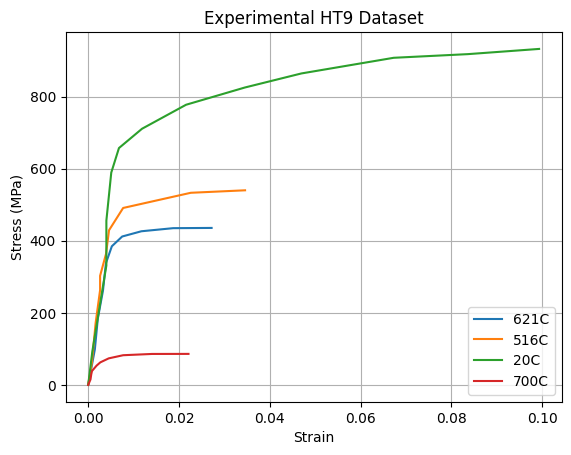

In [104]:
# Load experimental data
path = '/home/colinmoose/neml2/cmg_projects/tensile_data/HT9_var_temp_and_erate'
data_frames = {}
for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        if 'RT' in filename:
            temp_label = '20'
        elif '516' in filename:
            temp_label = '516'
        elif '621' in filename:
            temp_label = '621'
        elif '700' in filename:
            temp_label = '700'
        else:
            temp_label = 'unknown'
        
        new_df = df.rename(columns={'x':f'{temp_label}_strain', 'y':f'{temp_label}_stress'})
        data_frames[temp_label] = new_df

strain_data = {}
stress_data = {}

for temp_label, df in data_frames.items():
    strain_col = f'{temp_label}_strain'
    stress_col = f'{temp_label}_stress'
    strain = torch.tensor(df[strain_col].values, device=device)
    stress = torch.tensor(df[stress_col].values, device=device)
    max_stress_idx = torch.argmax(stress).item()
    strain = strain[:max_stress_idx + 1]
    stress = stress[:max_stress_idx + 1]
    strain = strain[:] - strain[0]
    stress = stress[:] - stress[0]
    strain_data[temp_label] = strain
    stress_data[temp_label] = stress

# Plot initial dataset
plt.figure()
for temp_label in strain_data:
    plt.plot(strain_data[temp_label].cpu().numpy(), stress_data[temp_label].cpu().numpy(), label=f"{temp_label}C")
plt.xlabel('Strain')
plt.ylabel('Stress (MPa)')
plt.title('Experimental HT9 Dataset')
plt.grid()
plt.legend()
plt.show()

In [105]:
nrate = 4
ntemperature = 4
nbatch = 4
ntime = 100
rates = torch.tensor([1.0e-4, 4.0e-5, 4.0e-3, 1.38e-6], device=device)
# Temperatures in Kelvin (required by k_B = 8.617e-5 eV/K in the thermally activated mobility model)
temperatures = torch.tensor([293.15, 789.15, 894.15, 973.15], device=device)
print(f"--- Initial Experimental Conditions ---\nstrain rates:\n{rates}\ntemperatures (K):\n{temperatures}")


--- Initial Experimental Conditions ---
strain rates:
tensor([1.0000e-04, 4.0000e-05, 4.0000e-03, 1.3800e-06], device='cuda:0')
temperatures (K):
tensor([293.1500, 789.1500, 894.1500, 973.1500], device='cuda:0')


In [106]:
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, T in enumerate(temperatures):
    # t_label uses Celsius for dict lookup (data was loaded with Celsius keys)
    t_label = str(int(T.item() - 273))
    # Get the actual strain range from experimental data
    min_strain = strain_data[t_label].min().item()
    max_strain = strain_data[t_label].max().item()
    
    print(f"Temperature {t_label}C ({T.item():.2f}K): strain range [{min_strain:.4f}, {max_strain:.4f}]")
    print(f'{rates[i].item()}')
    
    # Create loading (strain) values within this range
    strain_values = torch.linspace(min_strain, max_strain, ntime, device=device)
    time_values = torch.linspace(min_strain, max_strain/rates[i].item(), ntime, device=device)
    loading[:, i, 0] = strain_values
    time[:, i, 0] = time_values
    
    # Set temperature (in Kelvin)
    temperature[:, i, 0] = T

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")


Temperature 20C (293.15K): strain range [0.0000, 0.0993]
0.0001
Temperature 516C (789.15K): strain range [0.0000, 0.0346]
4e-05
Temperature 621C (894.15K): strain range [0.0000, 0.0272]
0.004
Temperature 700C (973.15K): strain range [0.0000, 0.0221]
1.38e-06

--- Full Input Tensors ---
time: torch.Size([100, 4, 1])
temperature: torch.Size([100, 4, 1])
loading: torch.Size([100, 4, 6])


Initial data size for 621: torch.Size([10])
Initial data size for 516: torch.Size([10])
Initial data size for 20: torch.Size([14])
Initial data size for 700: torch.Size([10])
Interpolated data shape:
strain: torch.Size([100, 4, 6])
stress: torch.Size([100, 4, 6])


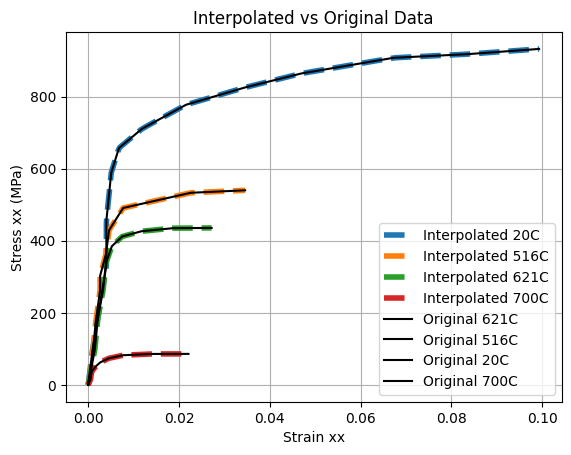

In [107]:
# Initial data shape
for temp_label in strain_data:
    print(f"Initial data size for {temp_label}: {stress_data[temp_label].shape}")

exp_stress_data = torch.zeros_like(loading, device=device)
exp_strain_data = torch.zeros_like(loading, device=device)

for i, T in enumerate(temperatures):
    # t_label in Celsius for dict lookup
    t_label = str(int(T.item() - 273))
    
    f_strain = torch.nn.functional.interpolate(strain_data[t_label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    f_stress = torch.nn.functional.interpolate(stress_data[t_label].unsqueeze(0).unsqueeze(0), size=ntime, mode='linear', align_corners=True).squeeze()
    
    exp_strain_data[:, i, 0] = f_strain
    exp_stress_data[:, i, 0] = f_stress
    
print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

# Plot interpolated data
plt.figure()
for i, T in enumerate(temperatures):
    t_label = str(int(T.item() - 273))
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), '--', color=f'C{i}', lw=4, label=f"Interpolated {t_label}C")
for temp_label in strain_data:
    plt.plot(strain_data[temp_label].cpu().numpy(), stress_data[temp_label].cpu().numpy(), color='k', label=f"Original {temp_label}C")
plt.xlabel("Strain xx")
plt.ylabel("Stress xx (MPa)")
plt.title("Interpolated vs Original Data")
plt.grid()
plt.legend()
plt.show()


Temp 20C: E = 100000.00 MPa, E_exp = 101807.47 MPa
  Yield stress: 676.74 MPa at strain: 0.0086
Temp 516C: E = 75000.00 MPa, E_exp = 76634.31 MPa
  Yield stress: 492.91 MPa at strain: 0.0084
Temp 621C: E = 67000.00 MPa, E_exp = 67211.36 MPa
  Yield stress: 413.98 MPa at strain: 0.0082
Temp 700C: E = 30000.00 MPa, E_exp = 29890.25 MPa
  Yield stress: 73.25 MPa at strain: 0.0045


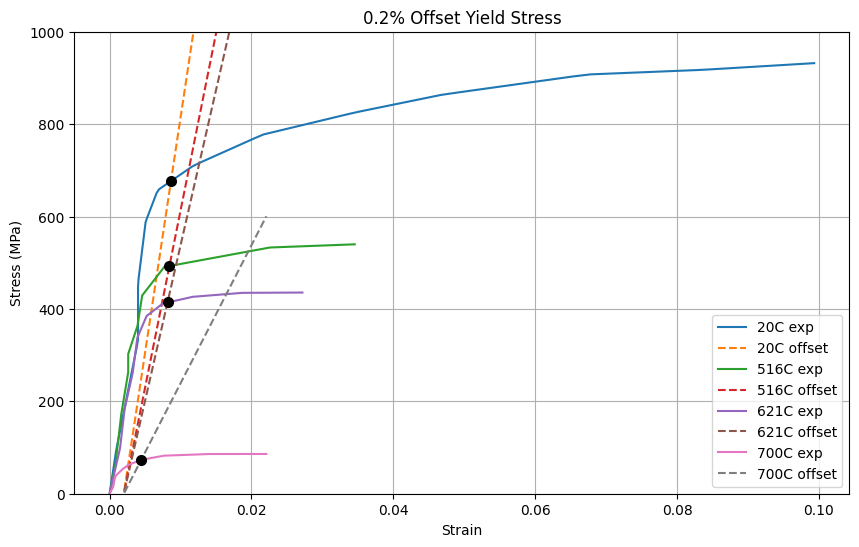


Experimental E values: [101807.46502653  76634.31232093  67211.3619677   29890.25012762]
Experimental sy values: [676.73816576 492.90807825 413.98290585  73.25199063]
Experimental G values: [39156.7173179  29474.73550805 25850.52383373 11496.25004908]


In [108]:
# Find the yield stress for each temperature
E = nmodel.E_Y.tensor().clone().torch()  # interpolation ordinate for E
sy = nmodel.sy_Y.tensor().clone().torch()  # interpolation ordinate for sy
nu = nmodel.elasticity_nu.tensor().clone().torch()
offset = 0.002

sy_exps = []
E_exps = []

plt.figure(figsize=(10, 6))

for i, T in enumerate(temperatures):
    temp_label = str(int(T.item() - 273))  # Celsius label for display/lookup

    # Calculate actual experimental Young's Modulus
    strain_initial = exp_strain_data[:5, i, 0].cpu().numpy()
    stress_initial = exp_stress_data[:5, i, 0].cpu().numpy()
    E_exp = np.polyfit(strain_initial, stress_initial, 1)[0]
    E_exps.append(E_exp)
    print(f"Temp {temp_label}C: E = {E[i]:.2f} MPa, E_exp = {E_exp:.2f} MPa")

    # Grab experimental data (keep on GPU)
    stress_exp = exp_stress_data[:, i, 0]
    strain_range = exp_strain_data[:, i, 0]

    # Build 0.2% offset line: E * (strain - 0.002), zero below offset
    valid_idx = strain_range >= offset
    stress_offset = torch.zeros_like(strain_range)
    stress_offset[valid_idx] = E_exp * (strain_range[valid_idx] - offset)

    # Find yield point: first sign change of (stress_exp - stress_offset) in valid region
    diff = stress_exp - stress_offset
    diff_valid = diff[valid_idx]
    strain_valid = strain_range[valid_idx]
    stress_valid = stress_exp[valid_idx]

    sign_changes = torch.where(torch.diff(torch.sign(diff_valid)) != 0)[0]

    if len(sign_changes) > 0:
        idx = sign_changes[0].item()
        # Linear interpolation between the two bracketing points
        d0, d1 = diff_valid[idx].item(), diff_valid[idx + 1].item()
        s0, s1 = strain_valid[idx].item(), strain_valid[idx + 1].item()
        se0, se1 = stress_valid[idx].item(), stress_valid[idx + 1].item()

        t = d0 / (d0 - d1)  # interpolation parameter in [0, 1]
        yield_strain = s0 + t * (s1 - s0)
        yield_stress = se0 + t * (se1 - se0)

        sy_exps.append(yield_stress)
        print(f"  Yield stress: {yield_stress:.2f} MPa at strain: {yield_strain:.4f}")
        plt.plot(yield_strain, yield_stress, "ko", markersize=7, zorder=5)
    else:
        print(f"  WARNING: No intersection found for {temp_label}C; using current model sy for this temperature")
        sy_exps.append(float(sy[i].item()))

    # Plot experimental curve and offset line
    plt.plot(strain_range.cpu().numpy(), stress_exp.cpu().numpy(), "-", label=f"{temp_label}C exp")
    plt.plot(
        strain_range[valid_idx].cpu().numpy(),
        stress_offset[valid_idx].cpu().numpy(),
        "--",
        label=f"{temp_label}C offset",
    )

plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("0.2% Offset Yield Stress")
plt.legend()
plt.grid()
plt.ylim((0.0, 1000.0))
plt.show()

# Replace model parameters with experimental values to improve training
E_exps = np.array(E_exps)
sy_exps = np.array(sy_exps)

# Compute G from experimental E: G = E / (2*(1+nu))
G_exps = E_exps / (2.0 * (1.0 + nu.cpu().numpy()))

print(f"\nExperimental E values: {E_exps}")
print(f"Experimental sy values: {sy_exps}")
print(f"Experimental G values: {G_exps}")

# For interpolation models these are ordinate vectors; enforce strict length = ntemperature
if len(E_exps) != ntemperature or len(sy_exps) != ntemperature or len(G_exps) != ntemperature:
    raise RuntimeError(
        f"Parameter vector length mismatch: E={len(E_exps)}, sy={len(sy_exps)}, G={len(G_exps)}, expected {ntemperature}"
    )

E_tensor = torch.tensor(E_exps, device=device, dtype=torch.double)
sy_tensor = torch.tensor(sy_exps, device=device, dtype=torch.double)
G_tensor = torch.tensor(G_exps, device=device, dtype=torch.double)

# with torch.no_grad():
#     E_param = nmodel.E_Y.tensor().torch()
#     sy_param = nmodel.sy_Y.tensor().torch()
#     G_param = nmodel.G_Y.tensor().torch()

#     if E_param.numel() != ntemperature or sy_param.numel() != ntemperature or G_param.numel() != ntemperature:
#         raise RuntimeError(
#             f"Model interpolation ordinate size mismatch: E_Y={E_param.numel()}, sy_Y={sy_param.numel()}, G_Y={G_param.numel()}, expected {ntemperature}"
#         )

#     E_param.copy_(E_tensor)
#     sy_param.copy_(sy_tensor)
#     G_param.copy_(G_tensor)
#     print(f"Updated E_Y:  {nmodel.E_Y.tensor().torch()}")
#     print(f"Updated sy_Y: {nmodel.sy_Y.tensor().torch()}")
#     print(f"Updated G_Y:  {nmodel.G_Y.tensor().torch()}")

In [109]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)

tensor([[[  0.0000],
         [  0.0000],
         [  0.0000],
         [  0.0000]],

        [[ 10.3389],
         [  3.0392],
         [  1.7246],
         [  0.5214]],

        [[ 20.2828],
         [  6.0383],
         [  3.4269],
         [  1.0380]],

        [[ 29.8438],
         [  8.9977],
         [  5.1106],
         [  1.5498]],

        [[ 39.0337],
         [ 11.9177],
         [  6.7757],
         [  2.0569]],

        [[ 47.8639],
         [ 14.7987],
         [  8.4225],
         [  2.5593]],

        [[ 56.3462],
         [ 17.6412],
         [ 10.0512],
         [  3.0570]],

        [[ 64.4917],
         [ 20.4455],
         [ 11.6618],
         [  3.5500]],

        [[ 72.3116],
         [ 23.2121],
         [ 13.2545],
         [  4.0385]],

        [[ 79.8169],
         [ 25.9412],
         [ 14.8296],
         [  4.5224]],

        [[ 87.0182],
         [ 28.6334],
         [ 16.3871],
         [  5.0018]],

        [[ 93.9260],
         [ 31.2889],
         [ 1

/home/colinmoose/miniforge/envs/neml2/lib/python3.13/site-packages/pyzag/chunktime.py:114: UserWarning: Implicit solve did not succeed.  Results may be inaccurate...
  warnings.warn(


Text(0.5, 1.0, 'Initial Comparison')

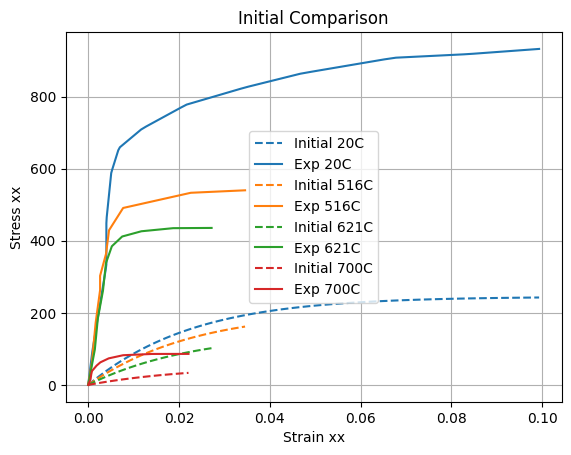

In [110]:
for i, T in enumerate(temperatures):
    t_label = str(int(T.item() - 273))  # Celsius label for display
    plt.plot(loading[:, i, 0].detach().cpu(), stress[:, i, 0].detach().cpu(), '--', color=f'C{i}',label=f"Initial {t_label}C")
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), color=f'C{i}',label=f'Exp {t_label}C')
plt.xlabel("Strain xx")
plt.ylabel("Stress xx")
plt.legend()
plt.grid()
plt.title("Initial Comparison")


In [86]:
initial_params = {}
print("--- Before Reparametrization ---")
for n, p in model.named_parameters():
    initial_params[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.Bk_Y: tensor([0.0001, 0.0001, 0.0001, 0.0001], device='cuda:0'), torch.Size([4])

discrete_equations.C_Y: tensor([15000., 12000.,  9000.,  4500.], device='cuda:0'), torch.Size([4])

discrete_equations.H_0_Y: tensor([0.6500, 0.6500, 0.6500, 0.6500], device='cuda:0'), torch.Size([4])

discrete_equations.T_0_Y: tensor([234.5200, 631.3200, 715.3200, 778.5200], device='cuda:0'), torch.Size([4])

discrete_equations.g_Y: tensor([4.0000, 3.8000, 4.2000, 5.5000], device='cuda:0'), torch.Size([4])

discrete_equations.k1_Y: tensor([1.0000, 6.0000, 5.5000, 4.5000], device='cuda:0'), torch.Size([4])

discrete_equations.k2_Y: tensor([2.0000, 2.0000, 2.2000, 2.5000], device='cuda:0'), torch.Size([4])

discrete_equations.m_Y: tensor([0.3000, 0.3000, 0.3000, 0.3000], device='cuda:0'), torch.Size([4])

discrete_equations.p_Y: tensor([0.5000, 0.5000, 0.5000, 0.5000], device='cuda:0'), torch.Size([4])

discrete_equations.q_Y: tensor([1.2500, 1.2500, 1.25

In [88]:
Bk_scaler = reparametrization.RangeRescale(torch.tensor([1.0e-8, 1.0e-8, 1.0e-8, 1.0e-8], device=device), torch.tensor([50.0, 50.0, 50.0, 50.0], device=device))
C_scaler = reparametrization.RangeRescale(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device), torch.tensor([1.0e10, 1.0e10, 1.0e10, 1.0e10], device=device))
H_0_scaler = reparametrization.RangeRescale(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device), torch.tensor([50.0, 50.0, 50.0, 50.0], device=device))
T_0_scaler = reparametrization.RangeRescale(torch.tensor([10.0, 10.0, 10.0, 10.0], device=device), torch.tensor([5000.0, 5000.0, 5000.0, 5000.0], device=device))
g_scaler = reparametrization.RangeRescale(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device), torch.tensor([50.0, 50.0, 50.0, 50.0], device=device))
k1_scaler = reparametrization.RangeRescale(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device), torch.tensor([50.0, 50.0, 50.0, 50.0], device=device))
k2_scaler = reparametrization.RangeRescale(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device), torch.tensor([500.0, 500.0, 500.0, 500.0], device=device))
m_scaler = reparametrization.RangeRescale(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device), torch.tensor([0.5, 0.5, 0.5, 0.5], device=device))
p_scaler = reparametrization.RangeRescale(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device), torch.tensor([10.0, 10.0, 10.0, 10.0], device=device))
q_scaler = reparametrization.RangeRescale(torch.tensor([0.0, 0.0, 0.0, 0.0], device=device), torch.tensor([10.0, 10.0, 10.0, 10.0], device=device))
sy_scaler = reparametrization.RangeRescale(torch.tensor([25.0, 25.0, 25.0, 25.0], device=device), torch.tensor([800.0, 800.0, 800.0, 800.0], device=device))
tau_p_scaler = reparametrization.RangeRescale(torch.tensor([5.0, 5.0, 5.0, 5.0], device=device), torch.tensor([1.0e4, 1.0e4, 1.0e4, 1.0e4], device=device))

model_reparameterizer = reparametrization.Reparameterizer(
    {"discrete_equations.Bk_Y": Bk_scaler,
     "discrete_equations.C_Y": C_scaler,
     "discrete_equations.H_0_Y": H_0_scaler,
     "discrete_equations.T_0_Y": T_0_scaler,
     "discrete_equations.g_Y": g_scaler,
     "discrete_equations.k1_Y": k1_scaler,
     "discrete_equations.k2_Y": k2_scaler,
     "discrete_equations.m_Y": m_scaler,
     "discrete_equations.p_Y": p_scaler,
     "discrete_equations.q_Y": q_scaler,
     "discrete_equations.sy_Y": sy_scaler,
     "discrete_equations.tau_p_Y": tau_p_scaler}, error_not_provided=True)
model_reparameterizer(model)
print(f'--- After Reparameterization ---')
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f'{n}: {p.data}, requires_grad={p.requires_grad}')

--- After Reparameterization ---
discrete_equations.parametrizations.Bk_Y.original: tensor([1.9998e-06, 1.9998e-06, 1.9998e-06, 1.9998e-06], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.C_Y.original: tensor([1.5000e-06, 1.2000e-06, 9.0000e-07, 4.5000e-07], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.H_0_Y.original: tensor([0.0130, 0.0130, 0.0130, 0.0130], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.T_0_Y.original: tensor([0.0450, 0.1245, 0.1413, 0.1540], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.g_Y.original: tensor([0.0800, 0.0760, 0.0840, 0.1100], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k1_Y.original: tensor([0.0200, 0.1200, 0.1100, 0.0900], device='cuda:0'), requires_grad=True
discrete_equations.parametrizations.k2_Y.original: tensor([0.0040, 0.0040, 0.0044, 0.0050], device='cuda:0'), requires_grad=True
discrete_equations.parametrizati

In [90]:
niter = 1000
lr = 1.0e-4
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []
for i in titer:
    optimizer.zero_grad()
    res = model(time, temperature, loading)
    loss = loss_fn(res, exp_stress_data[...,0:1])
    loss.backward()
    loss_history.append(loss.detach().clone().cpu())
    titer.set_description("Loss: %3.2e" % loss_history[-1])
    optimizer.step()

plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.legend(loc="best")
plt.title("Loss history")

plt.figure()
plt.plot(range(len(loss_history)), loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.show()

Loss: nan: :   0%|          |2/1000


KeyboardInterrupt: 

Text(0.5, 1.0, 'Initial Comparison')

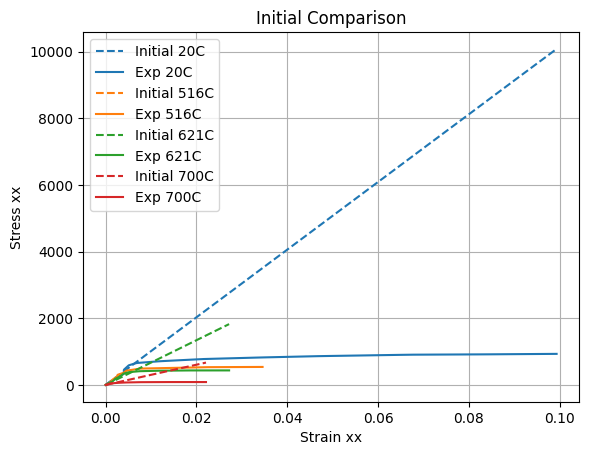

In [16]:
for i, T in enumerate(temperatures):
    t_label = str(int(T.item() - 273))  # Celsius label for display
    plt.plot(loading[:, i, 0].detach().cpu(), res[:, i, 0].detach().cpu(), '--', color=f'C{i}',label=f"Initial {t_label}C")
    plt.plot(exp_strain_data[:, i, 0].cpu().numpy(), exp_stress_data[:, i, 0].cpu().numpy(), color=f'C{i}',label=f'Exp {t_label}C')
plt.xlabel("Strain xx")
plt.ylabel("Stress xx")
plt.legend()
plt.grid()
plt.title("Initial Comparison")

In [17]:
print("Parameter Optimization Results:")
print("-" * 80)
for n, p in model.named_parameters():
    parts = n.split(".")
    if "parametrizations" in parts:
        param_idx = parts.index("parametrizations")
        simple_name = parts[param_idx - 1] + "." + parts[param_idx + 1]
    scaler = model_reparameterizer.map_dict[simple_name]
    final = scaler(p.data).cpu()
    print(f"\nParameter: {n}")
    print(f"  Initial:  {initial_params[simple_name].cpu()}")
    print(f"  Final:    {final}")
print("-" * 80)

Parameter Optimization Results:
--------------------------------------------------------------------------------

Parameter: discrete_equations.parametrizations.Bk_Y.original
  Initial:  tensor([0.0001, 0.0001, 0.0002, 0.0003])
  Final:    tensor([0.3002, 0.2961, 0.2998, 0.3005])

Parameter: discrete_equations.parametrizations.C_Y.original
  Initial:  tensor([12000.,  8000.,  5000.,  2500.])
  Final:    tensor([45037924.2587, 59216876.8712, 58960347.5599, 59224252.2793])

Parameter: discrete_equations.parametrizations.H_0_Y.original
  Initial:  tensor([0.5000, 0.6500, 0.7000, 0.8500])
  Final:    tensor([0.4525, 2.5921, 1.3141, 0.5663])

Parameter: discrete_equations.parametrizations.T_0_Y.original
  Initial:  tensor([234.5200, 631.3200, 715.3200, 778.5200])
  Final:    tensor([242.0690, 449.4216, 642.2111, 807.2232])

Parameter: discrete_equations.parametrizations.g_Y.original
  Initial:  tensor([4.0000, 5.0000, 6.5000, 8.0000])
  Final:    tensor([4.5738, 4.7540, 6.2884, 7.7580])

Pa